<a href="https://colab.research.google.com/github/HuBiZuk/AI_Study/blob/main/03_01_k%EC%B5%9C%EA%B7%BC%EC%A0%91%EC%9D%B4%EC%9B%83%ED%9A%8C%EA%B7%80%EC%95%8C%EA%B3%A0%EB%A6%AC%EC%A6%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
이번에는 겨울에 대방어철로 대방어가 주문이 크게 늘어서
MBC마켓에서 업계 최초로 농어를 무게 단위로 판매하려함
무게단위로 판매를 하면 가격 측정도 원할하고
고객도 합리적으로 판단을 할 수 있다.
그런데 공급처에서 생선 무게를 잘못해서 보낼수도 있다.
대방어의 무게를 재 측정해야 한다.
다른 데이터는 정상범위가 있으니 예측할 수 있을까?
이렇게 예측하는 것을 회귀라고 한다.
샘플 데이터가 필요하겠군!
외부에서 56개의 샘플을 받아서 처리해보자
지도학습은 크게 2가지로 나누어 짐

분류 (2진 분류) : from sklearn.neighbord import KNeighnorsClassifier
회귀 (예측 : 확률(임의의 어떤 숫자로 예측): from sklearn.neighbord import KNeighnorsRegressor
회귀 : 두 변수 사이에 상관관계를 분석하는 방법

"""


In [ ]:
# 리눅스 명령어로 코랩의 가상머신에 나눔폰트를 설치하고 적용하는 명령어
# 차트에 한글처리용
"""
!sudo apt-get install -y fonts-nanum # !sudo 가상머신 명령어 처리(관리자권한)
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf #설치 후에 세션 다시 시작!
"""

In [ ]:
# 대방어의 샘플자료 56개
import numpy as np

perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0]) # 대방어의 길이 배열리스트
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0]) # 대방어의 무게 배열리스트

기초자료


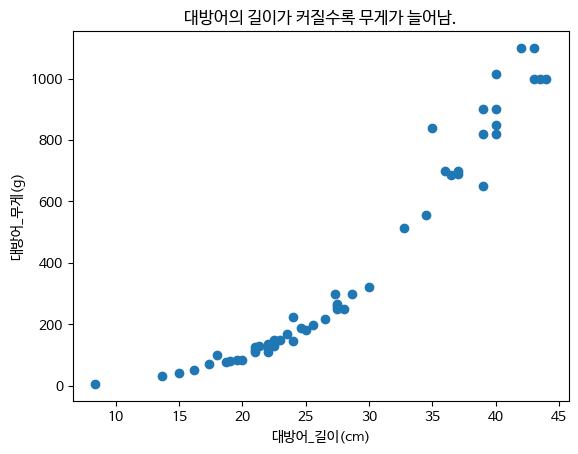

In [4]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic') # 한글처리

plt.scatter(perch_length, perch_weight) # 대방어의 길이(x축), 대방어의 무게(y축)
plt.xlabel('대방어_길이(cm)')
plt.ylabel('대방어_무게(g)')
print('기초자료')
plt.title('대방어의 길이가 커질수록 무게가 늘어남.')
plt.show()
# 산점도를 그리고 나니 길이가 커짐에 따라 무게도 늘어남
# 이 데이터를 토대로 훈연(.fit)과 테스트(.score)를 진행해 보자.


In [ ]:
# k-최근접 이웃 알고리즘에서의 회귀 KNeighborsRegressor
# 예측하려는 샘플에 가장 가까운 샘플 k개를 선택한다.
# 이 샘플들의 클래스를 확인하여 다수 클래스를 새로운 클래스로 예측함
# k=3 라고  가정하면 2개의 다수가 있어 분류는 사각형으로 판단
# 회귀는 샘플에 가장 가까운 샘플 k 개를 선택
# 타깃값 100, 80, 60 을 더해 3으로 나눈 평균이 타깃 값으로 사용됨

In [7]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)
                                                                              # input         target
# stratify 사용하지 않음(분류용) -> 정답파일이 무게 확률이기 때문에
# 사이킷 런의 train_test_split 함수를 사용해 훈련세트와 테스트 세트로 나눔
# random_state=42 서로 같은 테스트를 위해 시드값 제공
# 사이킷 런에 사용할 훈련 세트는 2차원 배열을 사용함
# perch_length가 1차원 배열이기 때문에 이를 나눈 train_input솨 test_input 도 1차원 배열임
# [3,] -> [3,1] 2차원 배열을 사용해야 함으로 억지로 변환 reshape() 메서드 활용(4,)->(2,2)

In [8]:
test_array = np.array([1,2,3,4])
print(test_array.shape) # 현재 1차원 배열로 나오는데 이것을 억지로 2차원 배열 처리해야함

(4,)


In [10]:
# 2차원 배열로 변환
test_array = test_array.reshape(2,2) # 억지로 2차원 배열 만드는 기법
print(test_array.shape)
# 전에는 2개의 특성으로 사용했었기 때문에 자연스럽게 열이 2개인 2차원 배열을 사용했었지만
# 이번에는 특성이 1개로 수동 2차원 배열 만들어야함 -> 넘파이. reshape()활용
# (4,) ->2,2  크기로 바꿔줌


(2, 2)


In [11]:
print(test_array)

[[1 2]
 [3 4]]


In [12]:
# 입력 데이터인 train_input과 test_input을 2차원 배열로 바꾸어야함
# train_input (42,) -> (42, 1) -> train_input.reshape(42,1)
# 넘파이는 배열의 크기를 자동으로 지정하는 기능도 제공(-1) 값을 넣으면 된다.
train_input = train_input.reshape(-1,1) # -1 지정하면 원소 개수로 모두 채우라는 의미
  # 1은 두번째 크기를 1로
test_input = test_input.reshape(-1,1)
print(train_input.reshape, test_input.shape)

<built-in method reshape of numpy.ndarray object at 0x7c7521990870> (14, 1)


In [13]:
print(train_input)

[[19.6]
 [22. ]
 [18.7]
 [17.4]
 [36. ]
 [25. ]
 [40. ]
 [39. ]
 [43. ]
 [22. ]
 [20. ]
 [22. ]
 [24. ]
 [27.5]
 [43. ]
 [40. ]
 [24. ]
 [21. ]
 [27.5]
 [40. ]
 [32.8]
 [26.5]
 [36.5]
 [13.7]
 [22.7]
 [15. ]
 [37. ]
 [35. ]
 [28.7]
 [23.5]
 [39. ]
 [21. ]
 [23. ]
 [22. ]
 [44. ]
 [22.5]
 [19. ]
 [37. ]
 [22. ]
 [25.6]
 [42. ]
 [34.5]]


In [14]:
# 훈련시작
from sklearn.neighbors import KNeighborsRegressor # 회귀 알고리즘용 구현 클래스(리그레스)
# rom sklearn.neighbors import KNeighborsClassidier # 분류용

knr = KNeighborsRegressor() # 회귀용 객체 생성
# k- 최근접 이웃 회귀 모델을 훈련합니다
knr.fit(train_input, train_target) # 회귀용 훈련
#        방어 길이   방어 무게

KNeighborsRegressor()

In [15]:
knr.score(test_input, test_target)
#          테스트 길이, 테스트 무게
# 분류의 경우는 테스트 세트에 있는 샘플을 정확하게 분류한 개수의 비율 (정확도) -> 예측값

# 회귀인 경우에는 평가를 결정 계수라고 함. R^2
# R^2 =1 = ((타깃 - 예측)^2의 합) / ((타깃-평균))^2의 합)임
#타깃의 평균 정도를 예측하는 수준 -> R^2는 0에 가까워지고 예츢이 타깃에 가까워지면 1에 가까운
# 결과 99.28%로 예측이 가능한 수준

0.992809406101064

In [16]:
knr.predict([[15]]) #알고싶은값 출력 15cm -> 60g
# k최근접 5개 이웃에 대한 값 99.28%(60g)

array([60.])

In [17]:
knr.predict([[30]])

array([311.4])

In [19]:
# sklearn.metrics 패키지 아래 여러가지 측정도구 제공함
# mean_absolute_error 절대값 오차를 평균하여 반환

from sklearn.metrics import mean_absolute_error # 평균으로 절대값의 오차를 찾는 메서드

# 테스트 세트에 대한 예측(prediction)을 만듬
test_predictions = knr.predict(test_input)

mae = mean_absolute_error(test_target, test_predictions)
# 테스트 세트에 대한 평균 정댓값 오차를 계산 함

print(mae)


19.157142857142862


In [20]:
print(knr.score(train_input, train_target))


0.9698823289099254


In [21]:
print(knr.score(test_input, test_target))

0.992809406101064


In [ ]:
"""
위 결과를 보면 모델을 훈련 세트에 훈련하면 훈련세트에 잘 맞는 모델이 만들어짐
이 모델을 훈련세트와 테스트 세트에서 평가하면 두값이 어느것이 높을까
보통 훈련세트의 점수가 조금 더 높게 나옴
# 훈련세트의 점수가 굉장히 좋았는데 테스트 세트에서는 점수가 굉장히 나쁘면 과대 적합이라고함
과소적합: 훈련세트보다 테스트세트가 점수가 높으면??? 두 점수사 모두 낮은 경우
"""

In [22]:
# 사이킷 런의 알고리즘 기본값을 3개로 조절 해보자

# 사이킷 런의 k-최근접 이웃 기본값이 5인데 이것을 3으로 변경
#이웃의 개수를 3으로 설정
knr.n_neighbors =3

# 모델 재훈련
knr.fit(train_input, train_target)
print(knr.score(train_input, train_target))


0.9804899950518966


In [23]:
knr.predict([[15]])
# 5개의 이웃을 참고하는것 (60.0) 보다 3개를 참고하는것이 더 좋은 결과가 나옴

array([47.33333333])

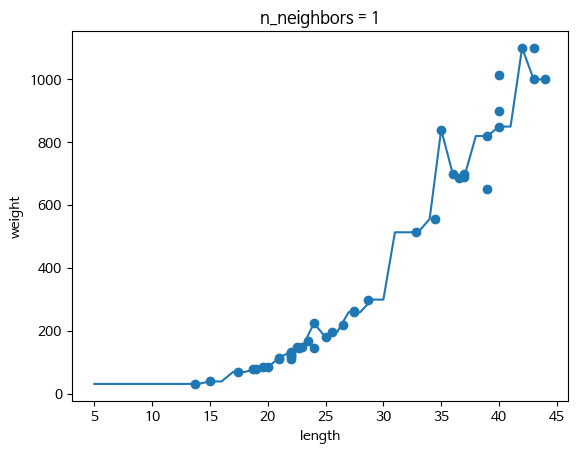

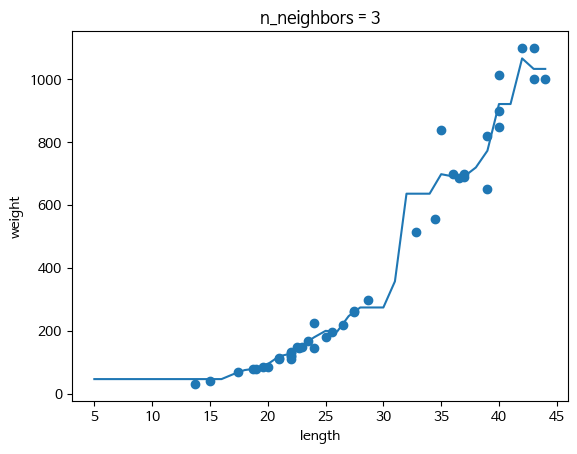

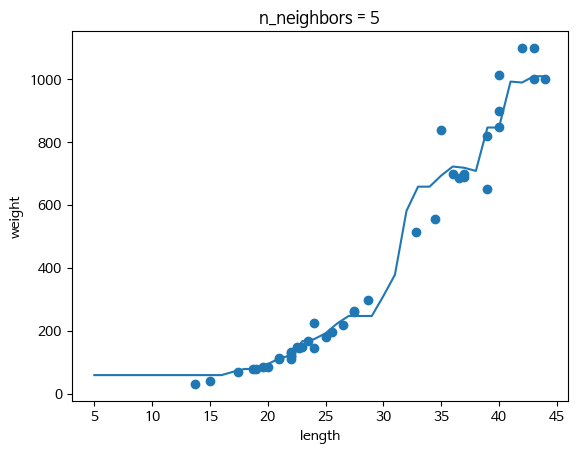

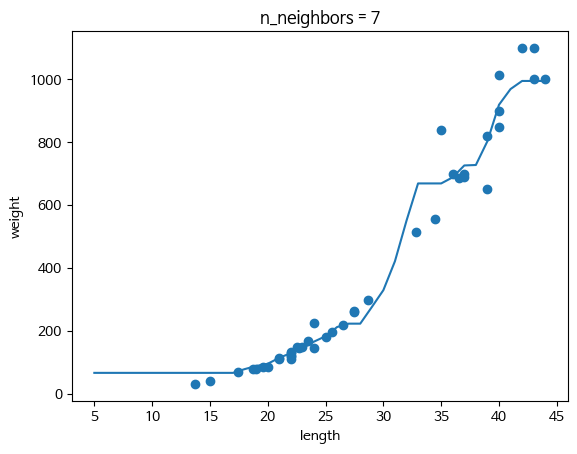

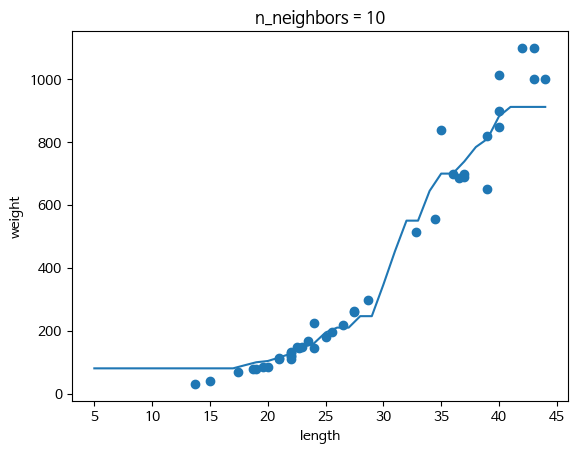

In [25]:

knr = KNeighborsRegressor()

x = np.arange(5,45).reshape(-1,1)

# Define a list of n_neighbors values to try
n_neighbors_values = [1, 3, 5, 7, 10] # You can adjust these values

for n in n_neighbors_values:
    knr.n_neighbors = n # Set the n_neighbors for the current iteration
    knr.fit(train_input, train_target)

    prediction = knr.predict(x)

    plt.figure() # Create a new figure for each plot
    plt.scatter(train_input, train_target) # Corrected typo: train_input
    plt.plot(x, prediction)
    plt.title('n_neighbors = {}'.format(n))
    plt.xlabel('length')
    plt.ylabel('weight')
    plt.show()